# The magic dataset

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [20]:
# On importe le datset
names = ["fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]
df = pd.read_csv("data/magic04.data", names = names)

In [21]:
# On convertis les classes g et h en classes binaires (0 et 1)
df["class"] = (df["class"] == "g").astype(int)

In [22]:
#maintenant g = 1 et h = 0
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


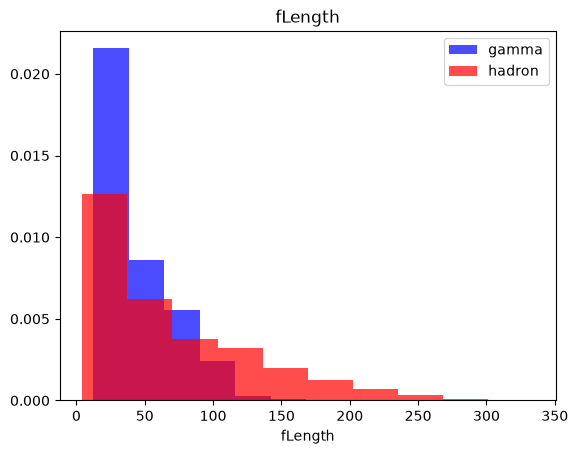

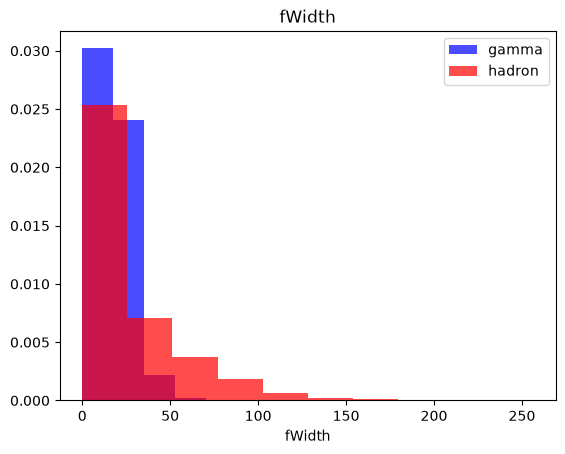

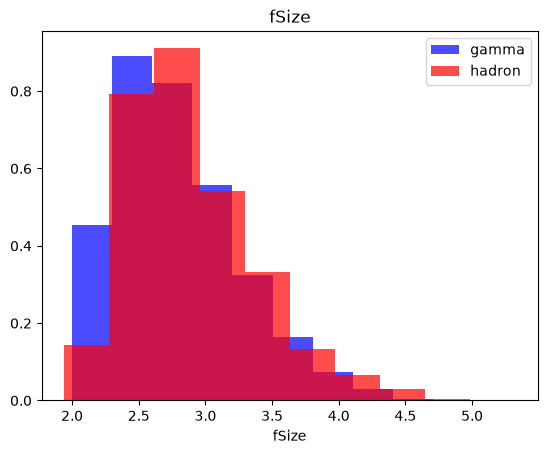

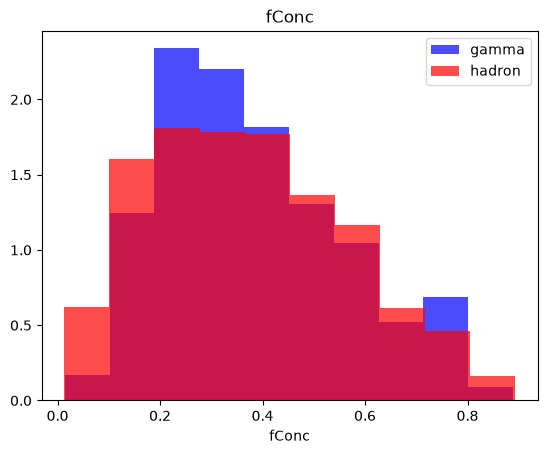

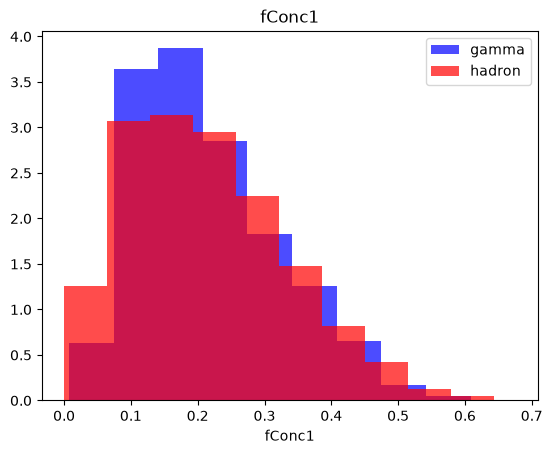

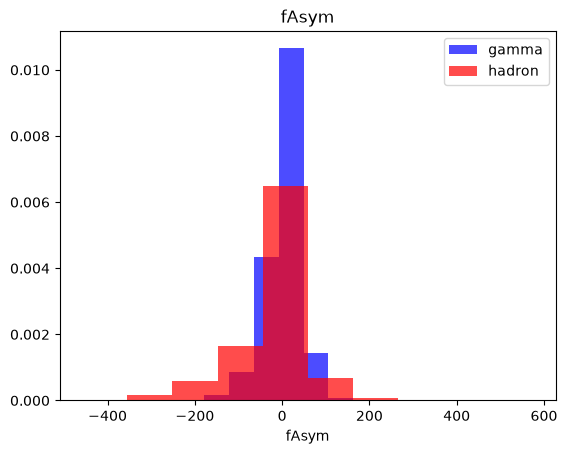

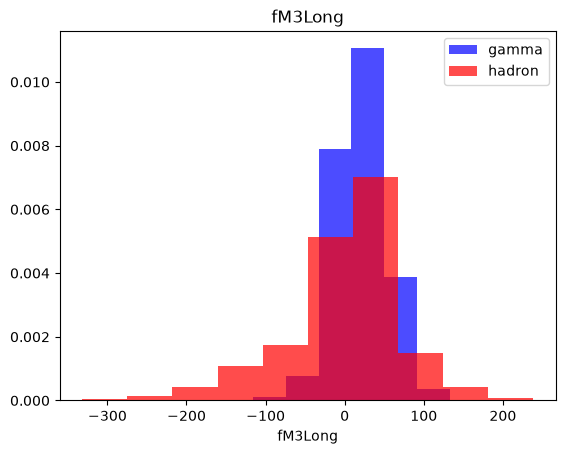

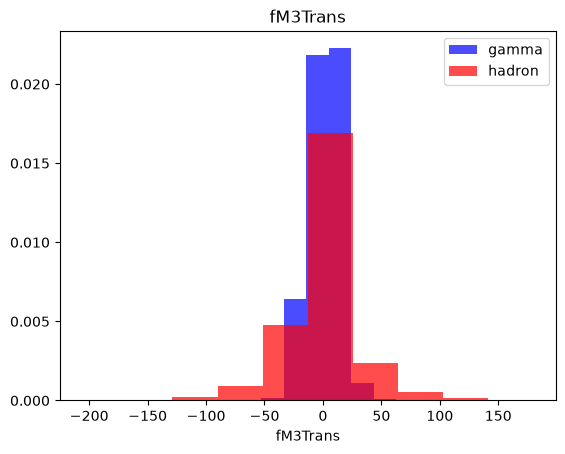

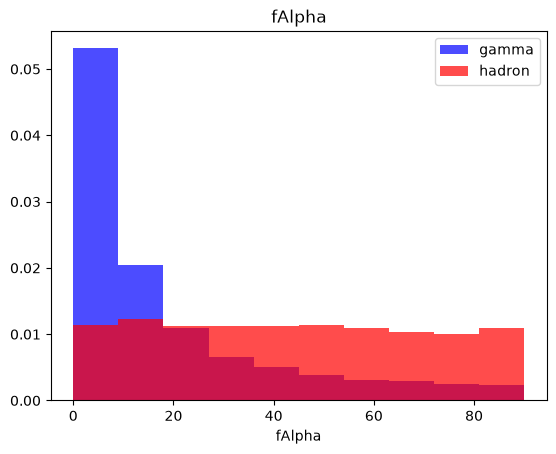

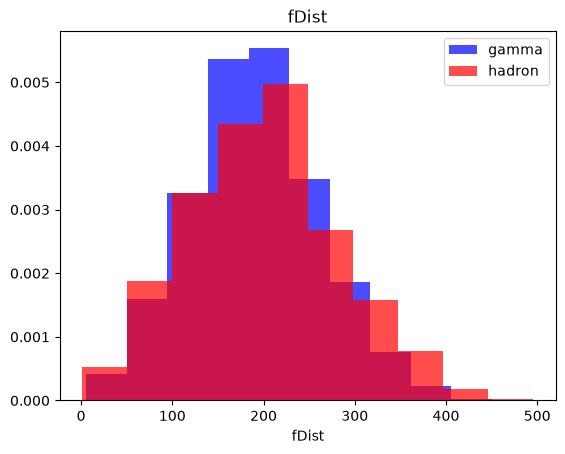

In [23]:
#regardons la distribution des features en fonction de la classe grâce a ça
for label in names[:-1]:
    plt.hist(df[df["class"] == 1][label], color = "blue", label = "gamma", alpha = 0.7, density=True)
    plt.hist(df[df["class"] == 0][label], color = "red", label = "hadron", alpha = 0.7, density=True)
    plt.title(label)
    plt.xlabel("probability")
    plt.xlabel(label)
    plt.legend()
    plt.show()

## Création des jeux de donnee de test, d'entrainement et de validation

In [73]:
#df sample permet de mélanger le dataset
#train, valid, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))]) #obsolète
train, temp = train_test_split(df, test_size=0.4, random_state=42) # on prend 60/40
valid, test = train_test_split(temp, test_size=0.5, random_state=42) #on coup les 40 en 2 pour avoir 20% et 20%

In [57]:
train.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
16773,19.9856,12.7567,2.6459,0.3979,0.2036,2.7455,0.5936,5.2597,42.7667,227.791,0
4274,19.1399,7.3049,2.1538,0.7930,0.4386,-4.4963,10.2828,-3.5350,47.8660,121.739,1
10319,87.8315,33.0873,3.5638,0.1119,0.0572,-95.0042,77.1037,-21.4400,4.7140,236.039,1
5400,31.5911,10.5484,2.4526,0.5044,0.2981,-23.6873,-26.5000,-5.8815,27.1412,182.470,1
5196,21.0228,16.2076,2.5670,0.4282,0.2236,-20.5324,-13.6002,-4.7962,22.6203,113.863,1


In [26]:
print(len(train))
print(len(valid))
print(len(test))

11412
3804
3804


In [60]:
#Création de la fonction pour scale toute les feature du dataset
def scale_dataset(dataframe, oversample = False):
    X = dataframe[dataframe.columns[:-1]].values
    y = dataframe[dataframe.columns[-1]].values

    scaler = StandardScaler()

    X = scaler.fit_transform(X)

    #Si necessaire, on peut faire en sorte d'avoir autant d'individus par catégorie grace a RandomOverSampler
    if oversample:
        ros = RandomOverSampler()
        X, y = ros.fit_resample(X, y)

    data = np.hstack((X, np.reshape(y, (-1, 1))))

    return data, X, y

In [74]:
train, X_train, y_train = scale_dataset(train, oversample=True)
valid, X_valid, y_valid = scale_dataset(valid, oversample=False)
test, X_test, y_test = scale_dataset(test, oversample=False)

In [75]:
#On vérifie que l'on a autant d'individu pour les 2 catégories
print(sum(y_train == 1))
print(sum(y_train == 0))

7396
7396
